In [ ]:
import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt


In [ ]:
df = pd.read_csv('/content/Housing.csv')

In [ ]:
df = df.dropna()

In [ ]:
median_price = df['price'].median()

df['price_category'] = (df['price'] >= median_price).astype(int)

df[['price', 'price_category']].head()

,price,price_category
0,13300000,1
1,12250000,1
2,12250000,1
3,12215000,1
4,11410000,1


In [ ]:
x = df.drop([
    'mainroad',
    'guestroom',
    'hotwaterheating',
    'airconditioning',
    'prefarea',
    'furnishingstatus',
    'basement',
    'price',
    'price_category'
], axis=1)

y = df['price_category']

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
model = LogisticRegression(max_iter=1000)

model.fit(x_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred = model.predict(x_test)

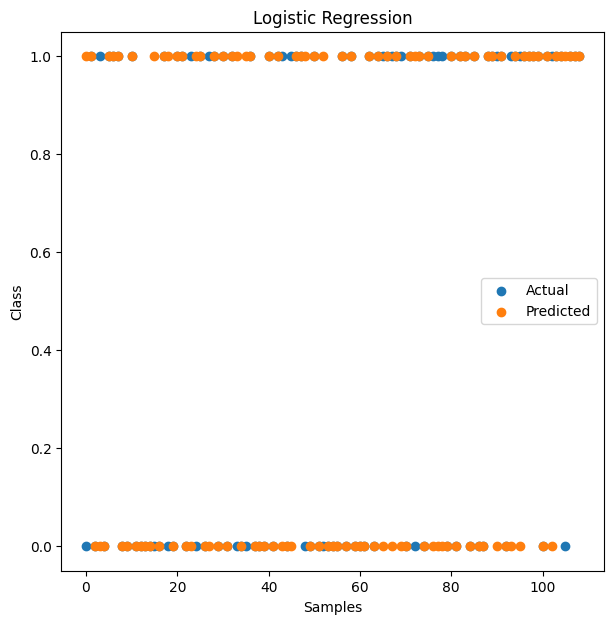

In [ ]:
plt.figure(figsize=(7, 7))

plt.scatter(range(len(y_test)), y_test, label="Actual")
plt.scatter(range(len(y_pred)), y_pred, label="Predicted")

plt.xlabel("Samples")
plt.ylabel("Class")
plt.title("Logistic Regression")
plt.legend()

plt.show()

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7706422018348624


In [ ]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[39 10]
 [15 45]]


In [ ]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.80      0.76        49
           1       0.82      0.75      0.78        60

    accuracy                           0.77       109
   macro avg       0.77      0.77      0.77       109
weighted avg       0.78      0.77      0.77       109

